# Người duyệt frame khó, phần còn lại máy chạy: tiết kiệm được bao nhiêu công?

Mô phỏng quy trình thật trên 2 scene nuScenes (40 keyframe): một "người duyệt chuẩn" quyết định theo GT nuScenes
(`scripts/simulate_review.py`, gọi đúng API mà UI dùng). Ở mỗi keyframe người đó:

- xem các box bị QA gắn cờ (medium / high) và Keep / đổi lớp / xoá đúng theo GT,
- duyệt theo lô các box low mà không xem (lỗi trong nhóm này lọt qua),
- vẽ thêm vật mà máy bỏ sót.

So sánh ba chế độ:

| Chế độ | Nghĩa |
|---|---|
| `none` | Không lan truyền: mỗi keyframe duyệt độc lập (như chế độ Ảnh) |
| `prop_coasting` | Lan truyền như bản trước: ghi cả box **chỉ dự đoán** (detector không thấy ở keyframe đích) |
| `prop` | Lan truyền bản hiện tại (`propagation.emit_coasting: false`): chỉ ghi box có detection đỡ |

Thời gian ước tính: 3 s cho mỗi box bị gắn cờ, 10 s cho mỗi vật vẽ thêm (sửa ở ô dưới).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RES = Path("results/review_sim") if Path("results/review_sim").exists() else Path("eval/results/review_sim")
SEC_FLAG, SEC_DRAW = 3, 10
MODES = {"none": "Không lan truyền", "prop_coasting": "Lan truyền (ghi cả box dự đoán)", "prop": "Lan truyền (hiện tại)"}
COLOR = {"none": "#52514e", "prop_coasting": "#eb6834", "prop": "#2a78d6"}
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#9a9994", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "axes.grid": True, "grid.color": "#e7e6e2", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "legend.frameon": False, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})

rows, runs = [], {}
for p in sorted(RES.glob("*.json")):
    r = json.loads(p.read_text())
    runs[(r["mode"], r["min_score"])] = r
    agg = {k: sum(s["stats"][k] for s in r["scenes"].values()) for k in ("flagged", "KEEP", "DELETE", "CHANGE_CLASS", "ADD_BOX")}
    fp = sum(s["quality"]["fp"] for s in r["scenes"].values())
    rows.append({"min_score": r["min_score"], "Chế độ": r["mode"], "Box phải xem": agg["flagged"], "Xoá": agg["DELETE"],
                 "Đổi lớp": agg["CHANGE_CLASS"], "Vẽ thêm": agg["ADD_BOX"], "Lỗi lọt (box sai còn lại)": fp,
                 "Phút": round((agg["flagged"] * SEC_FLAG + agg["ADD_BOX"] * SEC_DRAW) / 60, 1)})
df = pd.DataFrame(rows).sort_values(["min_score", "Chế độ"], key=lambda c: c.map({"none": 0, "prop_coasting": 1, "prop": 2}) if c.name == "Chế độ" else c)
df.set_index(["min_score", "Chế độ"])

Box phải xem  Xoá  Đổi lớp  Vẽ thêm  \
min_score Chế độ                                               
0.1       none                    274  220        2       61   
          prop_coasting           291  238        3       53   
          prop                    204  165        3       62   
0.3       none                     95   63        2       77   
          prop_coasting           184  137        3       52   
          prop                     95   64        2       62   

                         Lỗi lọt (box sai còn lại)  Phút  
min_score Chế độ                                          
0.1       none                                  69  23.9  
          prop_coasting                         61  23.4  
          prop                                  55  20.5  
0.3       none                                  63  17.6  
          prop_coasting                         66  17.9  
          prop                                  60  15.1

## Tổng công duyệt 40 keyframe

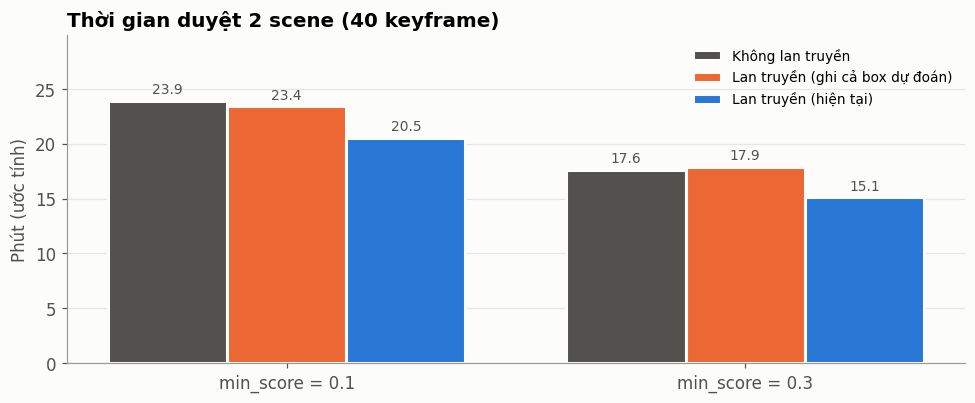

In [2]:
fig, ax = plt.subplots(figsize=(9, 3.8))
ths = sorted(df.min_score.unique())
w = 0.26
for k, m in enumerate(MODES):
    vals = [df[(df.min_score == t) & (df["Chế độ"] == m)]["Phút"].item() for t in ths]
    bars = ax.bar([i + (k - 1) * w for i in range(len(ths))], vals, width=w, color=COLOR[m], label=MODES[m],
                  edgecolor="#fcfcfb", linewidth=2)
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9, color="#52514e")
ax.set_xticks(range(len(ths)), [f"min_score = {t}" for t in ths])
ax.set_ylabel("Phút (ước tính)")
ax.set_title("Thời gian duyệt 2 scene (40 keyframe)")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right", fontsize=9)
ax.set_ylim(0, df["Phút"].max() * 1.25)
plt.tight_layout()
plt.show()

## Box phải xem theo từng keyframe (scene-0031, min_score 0.3)

Keyframe đầu người duyệt kỹ; các keyframe sau nhận nhãn lan truyền. Bản cũ ghi cả box chỉ dự đoán (detector không
thấy), phần lớn lệch khỏi vật nên bị gắn cờ `PROP_COASTING` và người phải xoá — lan truyền khi đó còn tốn công hơn
không lan truyền.

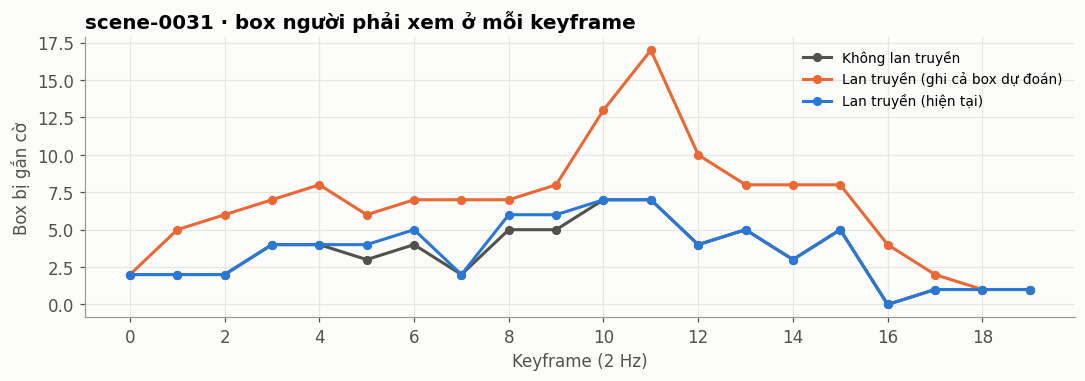

In [3]:
fig, ax = plt.subplots(figsize=(10, 3.6))
for m in MODES:
    pf = runs[(m, 0.3)]["scenes"]["scene-0031"]["per_frame"]
    ax.plot(range(len(pf)), [f["flagged"] for f in pf], marker="o", ms=5, lw=2, color=COLOR[m], label=MODES[m])
ax.set_xticks(range(0, len(pf), 2))
ax.set_xlabel("Keyframe (2 Hz)")
ax.set_ylabel("Box bị gắn cờ")
ax.set_title("scene-0031 · box người phải xem ở mỗi keyframe")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

## Kết luận (lần chạy 2026-09-28)

- **Bản lan truyền cũ không đỡ công.** Ở min_score 0.1: 23.4 phút so với 23.9 phút khi không lan truyền. Lý do: khoảng 90 box "chỉ dự đoán" (detector không thấy ở keyframe đích) được ghi ra, chỉ khoảng 15 box đúng, người phải xoá phần còn lại.
- **Bản hiện tại (`emit_coasting: false`) đỡ công thật.** So với không lan truyền, thời gian giảm 14% ở cả hai ngưỡng: ở 0.1 box phải xem 274 → 204; ở 0.3 số box phải xem bằng nhau (95) nhưng vật phải vẽ thêm ít hơn (77 → 62) vì nhãn đã được mang sang. Track vẫn chạy qua các ảnh sweep và bắt lại vật khi detector thấy lại, chỉ không ghi box đoán mò.
- **Kết hợp với min_score 0.3:** 15.1 phút so với 23.4 phút của cấu hình trước (0.1 + lan truyền cũ), **giảm 35%**. Số lỗi lọt qua gần như không đổi (55–66 box sai còn lại trong các chế độ, đều đến từ nhóm low duyệt theo lô).
- **Việc máy chưa làm được:** vật người vẽ thêm mà detector không thấy thì không được mang sang frame sau, người phải vẽ lại. Hướng tiếp: tracker theo nội dung ảnh (template / optical flow) cho các box này.
- **Giới hạn:** 2 scene, người duyệt mô phỏng theo GT (quyết định luôn đúng, không tính thời gian đọc cờ khác nhau), thời gian là ước tính 3 s/box xem, 10 s/vật vẽ.
